## Preamble
--- 
This section imports all relevant libraries, defines the main event generation function, and defines the (default) experiment parameters in a config dictionary.

In [1]:
import numpy as np
import pandas as pd
import time
#Parallel Processing
import asyncio
import sys
import ipyparallel as ipp
from ipyparallel.cluster.cluster import Cluster
#Plotting libraries
import matplotlib.pyplot as plt
#Validation
from scipy import integrate
from scipy.stats import linregress, chi2
from scipy.special import erf
from scipy.optimize import curve_fit, minimize_scalar

# Fix Windows event loop on Python 3.8+ for ZMQ compatibility - AI generated - used for parallel processing
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
print("Event loop policy set!") 

Event loop policy set!


In [2]:
#Complete independent workflow for a single particle.
def compute_single_particle(params, seed):
    """
    Generate particle decay and detector hit information.
    
    Returns:
    dict
        Dictionary containing particle decay parameters and detector hits:
        
        Always included:
            'Velocity' (float): Particle velocity in m/s
            'Decay Time' (float): Time to decay in seconds
            'Decay Position' (float): Z-position of decay in meters
            'Daughter x' (float): X-coordinate of daughter particle
            'Daughter y' (float): Y-coordinate of daughter particle
            'Daughter z' (float): Z-coordinate of daughter particle
            'phi' (float): Azimuthal angle in radians
            'n hits' (int): Number of detector hits (default 0)
        
        Conditionally included (set to np.nan if empty):
            'first_detector_idx' (int): Index of first detector hit
            'Unsmeared Hits' (list or np.nan): Pre-smear hits by detector
            'Smeared Hits' (list or np.nan): Smeared hits by detector
        Hit list structure:
            [[x1,y1], [x2,y2],...], where [xn,yn] returned if applicable.
    
    Notes:
    'Unsmeared Hits' and 'Smeared Hits' are only populated if detector hits occur.
    """
    #Import library to worker
    import numpy as np
    
    #Unpack global variables
    particle_count = params["particle_count"]
    mean_v = params["mean_beam_velocity"]
    std_v = params["std_beam_velocity"]
    mean_t = params["mean_lifetime"]
    detector_size = params["detector_side_length"]
    detector_smear = params["detector_smear"]
    detector_pos = params["detector_positions"]

    #Init random generator
    rng = np.random.default_rng(seed)
    
    #Distribution sampling for particle params
    v = rng.normal(loc=mean_v , scale=std_v)
    t  = rng.exponential(scale=mean_t)
    z = v * t

    #Daughter Particle Generation
    u = rng.uniform()
    phi = rng.uniform(0, 2*np.pi)
    theta = np.arccos(2*u - 1)
    daughterx, daughtery, daughterz = np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)

    #Base result
    result = {
            'Velocity'      : v,
            'Decay Time'    : t,
            'Decay Position': z,
            'Daughter x'    : daughterx,
            'Daughter y'    : daughtery,
            'Daughter z'    : daughterz,
            'phi'           : phi,
            'n hits'        : int(0)
                }

    #No need to compute hit/no hit if z direction is wrong
    if daughterz <= 0:
        return result
        
    unsmeared_hits = []
    smeared_hits = []
    n_hits = int(0)
    for idx, pos in enumerate(detector_pos):
        delta_z = pos - z

        #Go to next detector if particle decays after this one
        if delta_z < 0:
            continue

        x_hit = (daughterx/daughterz) * delta_z        
        y_hit = (daughtery/daughterz) * delta_z

        #Is there an unsmeared hit?
        if (abs(x_hit) <= detector_size) and (abs(y_hit) <= detector_size):
            #Add Hit smearing
            r = rng.normal(loc=0.0, scale = detector_smear) 
            theta = rng.uniform(0, np.pi)
            x_hit_smear = x_hit + r*np.cos(theta)
            y_hit_smear = y_hit + r*np.sin(theta)
            #Is there a smeared hit?
            if (abs(x_hit_smear) <= detector_size) and (abs(y_hit_smear) <= detector_size):
                #Set first detector hit index
                if n_hits == 0:
                    first_detector_idx = int(idx)
                #Record a hit for that particle
                n_hits += 1
                unsmeared_hits.append([x_hit, y_hit])
                smeared_hits.append([x_hit_smear,y_hit_smear])
        else:
            break #only break when the detector is missed, ignore smear effects.

    result["n hits"] = n_hits
    result["first_detector_idx"] = int(first_detector_idx) if n_hits > 0 else np.nan
    result['Unsmeared Hits'] = unsmeared_hits if unsmeared_hits else np.nan
    result['Smeared Hits'] = smeared_hits if smeared_hits else np.nan
    return result

In [3]:
#Parameters - set to assignment defaults 
Config = {
    'particle_count'       : int(1e7),
    'mean_beam_velocity'   : 2000,             #metres/second
    'std_beam_velocity'    : 100,         
    'mean_lifetime'        : 2.5e-3,           #seconds
    'detector_side_length' : 2.5,              #metres, divided by 2 as it goes in +/- directions. Square detector
    'detector_smear'       : 0.01,             #metres
    'detector_positions'   : [30, 35, 40, 45], #metres, enter sorted.
}

#Generate seed list. Useful for reproducibility of results.
seedlist =  list(range(Config["particle_count"])) #Simple seed list

## Computing Events
---
This section processes event generation in parallel. <br> <br>The `ipyparallel` library-related code was generated using Perplexity Research.<br>
Prompt: "Write me code using the ipyparallel library to start a cluster with 'Ncores' cores and adjustable chuck sizes, computing the 'compute_single_particle' function using 'configlist, seedlist' as arguments. Include a progress bar."

In [4]:
#Cluster startup
Ncores  = 10 #up to user
chunksize = min(max(1, Config["particle_count"] // (Ncores * 4)), 1000)
cluster = ipp.Cluster(n=Ncores)
cluster.start_and_connect_sync()
rc = cluster.connect_client_sync()
print("Cluster started and connected!")
lview = rc.load_balanced_view()      # This gives you the load-balanced view
lview.block = False                   

#Simulation
configlist = [Config] * Config["particle_count"]
s = time.time()
async_result = lview.map_async(compute_single_particle, configlist, seedlist,chunksize=chunksize)
e = time.time()
print(f"Prep took {e-s:.2g} seconds")

s = time.time()
#AI Generated Progress bar
total = len(configlist)
while not async_result.ready():
    done = async_result.progress
    print(f"Progress: {done} / {total} done", end="\r")
    time.sleep(0.5)

results = async_result.get()  #Block until results are all done
e = time.time()
print(f"All tasks complete! Took {e-s:.2g} seconds")
results = pd.DataFrame(results)

cluster.stop_cluster_sync()
rc.close()

Starting 10 engines with <class 'ipyparallel.cluster.launcher.LocalEngineSetLauncher'>


  0%|          | 0/10 [00:00<?, ?engine/s]

Cluster started and connected!
Prep took 20 seconds
All tasks complete! Took 73 seconds
Stopping controller
Failed to remove C:\Users\Rapha\.ipython\profile_default\log\ipcontroller-1764777532-5kxi-612544.log: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\Rapha\\.ipython\\profile_default\\log\\ipcontroller-1764777532-5kxi-612544.log'
Output for ipcontroller-1764777532-5kxi-612544:
2025-12-03 16:00:34.564 [IPController] task::task '9cfbacf2-62b7e7dbd09f64fcadbc7840_612544_9956' arrived on 9
2025-12-03 16:00:34.565 [IPController] task::task '9cfbacf2-62b7e7dbd09f64fcadbc7840_612544_9948' finished on 9
2025-12-03 16:00:34.565 [IPController] task::task '9cfbacf2-62b7e7dbd09f64fcadbc7840_612544_9957' arrived on 7
2025-12-03 16:00:34.567 [IPController] task::task '9cfbacf2-62b7e7dbd09f64fcadbc7840_612544_9945' finished on 7
2025-12-03 16:00:34.569 [IPController] task::task '9cfbacf2-62b7e7dbd09f64fcadbc7840_612544_9958' arrived on 2

## Data Handling
---
Here, the results are split into two different dataframes. All standard-format results are split into the `beam_results` df, whilst the event-by-event hit results are unpacked into a df of detector-by-detector hits.

In [5]:
results[results["Smeared Hits"].notna()].head(3)

,Velocity,Decay Time,Decay Position,Daughter x,Daughter y,Daughter z,phi,n hits,first_detector_idx,Unsmeared Hits,Smeared Hits
225,2148.847197,0.007508,16.132959,0.009621,0.076179,0.997048,1.445166,4,0.0,"[[0.13381123584813026, 1.059510512739507], [0....","[[0.13551055733657236, 1.0589928837615519], [0..."
302,1997.382243,0.001174,2.345235,-0.077954,-0.028845,0.996540,3.496000,1,0.0,"[[-2.163277519538958, -0.8004795562671821]]","[[-2.1664115339446424, -0.8035362756995035]]"
410,1966.955278,0.014238,28.005740,-0.674407,0.205957,0.709053,2.845198,1,0.0,"[[-1.8968147065555043, 0.5792686761826817]]","[[-1.9007728415415936, 0.5843327928768844]]"


In [6]:
#Split result dfs for handling
beam_results = results.iloc[:,:8] #All non-hitlist parameters
hit_results = results.iloc[:,8:] #All hitlist parameters

#Identify which rows in hit_results have NaN in 'Smeared Hits'
nan_mask = hit_results['Smeared Hits'].isna()
#Keep only rows where Smeared Hits is NOT NaN
hit_results = hit_results[~nan_mask].copy()

#Convert hit data entries into a 1-hit-per-row df
combined_data = []
for idx, row in hit_results.iterrows():
    first_det = row['first_detector_idx']
    unsmeared_hits = row['Unsmeared Hits']
    smeared_hits = row['Smeared Hits']
        
    #Unpack each hit
    for hit_offset, (unsmeared_hit, smeared_hit) in enumerate(zip(unsmeared_hits, smeared_hits)):
        detector_num = first_det + hit_offset #Find respective detector
        
        combined_data.append({
            'detector': int(detector_num),
            'unsmeared_x': unsmeared_hit[0],
            'unsmeared_y': unsmeared_hit[1],
            'smeared_x': smeared_hit[0],
            'smeared_y': smeared_hit[1]
        })
#Convert back to df
hit_results = pd.DataFrame(combined_data)
hit_results.head()

,detector,unsmeared_x,unsmeared_y,smeared_x,smeared_y
0,0,0.133811,1.059511,0.135511,1.058993
1,1,0.182059,1.441535,0.185070,1.438124
2,2,0.230307,1.823560,0.238472,1.821594
3,3,0.278555,2.205585,0.272874,2.204548
4,0,-2.163278,-0.800480,-2.166412,-0.803536


## Validation of Beam Particle Distribution
---
This section validates recorded velocity, lifetime, and decay position distributions by comparing them against their expected probability density functions. The PDF for the decay position is derived below as the convolution of velocity and lifetime distributions, which are pre-defined.<br><br>
Perplexity Research was used to generate the code to calculate the PDFs, using the equations below with the prompt: "Please generate python functions to compute each of these three latex equations".

**Plotting Velocity & Decay Time Distributions, and Finding the PDF for decay position**<br>
The distributions for particle velocity and decay time are outlined in the assignment brief as gaussian and exponential respectively. Therefore, we define their PDFs as:<br>
>$\displaystyle f_v(v) = \frac{1}{\sqrt{2\pi}\sigma}\exp[{-\frac{(v-\mu)^2}{2\sigma^2}}]$ ; $\: \:$ $f_t(t) = \frac{1}{\tau} e^{-t/\tau}$, $\: t \geq 0$

The decay position is $z = vt$. The joint PDF for $v$ and $t$ is $f_{v,t}(v,t) = f_v(v) \cdot f_t(t)$. Since the setup outlined above requires integrating over $z$ to compute geometric hit probabilities, we can substitute one of $v$ or $t$ for $z$. We choose $t=\frac{z}{v}$ because the velocity distribution is given directly, and for each possible velocity, the decay time to reach $z$ is uniquely determined - making integration over $v$ both natural and efficient. Therefore, 
>$\displaystyle f_{z,v}(z,v) = f_v(v) \cdot f_t(\frac{z}{v}) \frac{1}{|v|}$,

with the Jacobian $\frac{1}{|v|}$ coming from the change of variables. Continuing:
>$\displaystyle f_z(z) = \int^\infty_{-\infty}f_{z,v}(z,v) dv  = \int^\infty_{-\infty}\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(v-\mu)^2}{2\sigma^2}} \frac{1}{\tau |v|}e^{-\frac{z}{v\tau}} dv$

Since $\mu \gg 0$, we can restrict the integral to $v > 0 $. Therefore:
> $\displaystyle f_z(z) = \int^\infty_{0}\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(v-\mu)^2}{2\sigma^2}} \frac{1}{\tau v}e^{-\frac{z}{v\tau}} dv$ <br>

We will compute this numerically below as it does not have a closed-form.

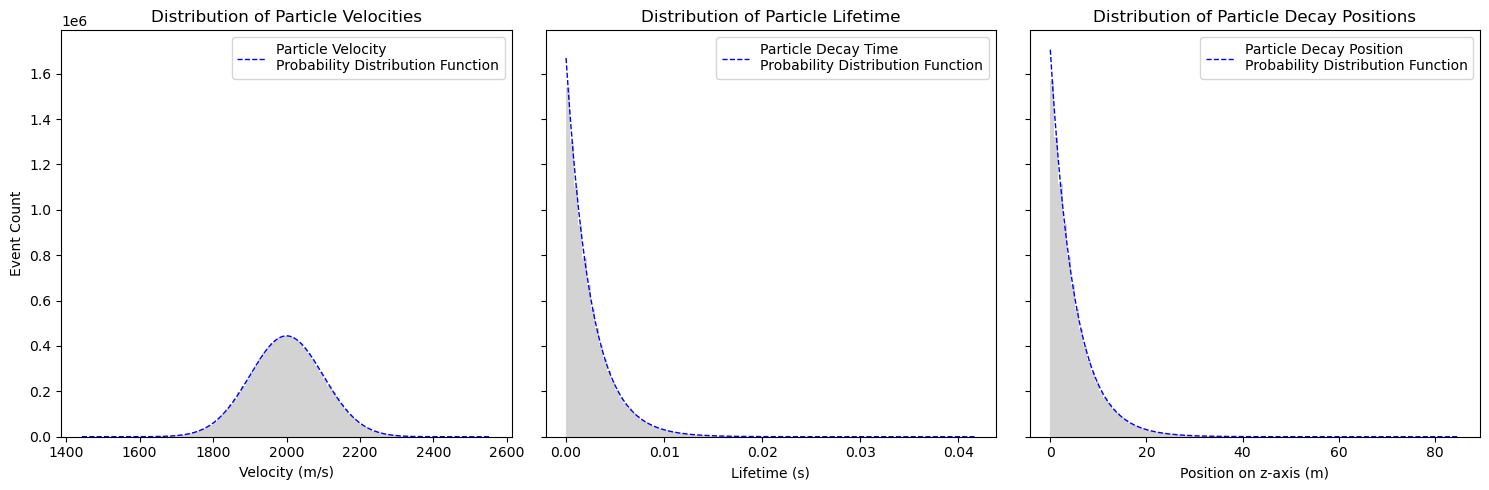

In [7]:
#PDFs, AI generated from above formulae.
def gaussian_pdf(x, mu, sigma):
    """Probability density function of a normal (Gaussian) distribution."""
    return (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-(x-mu)**2/(2*sigma**2))

def exponential_pdf(t, tau):
    """Probability density function of an exponential distribution (t≥0)."""
    pdf = np.zeros_like(t, dtype=float)
    mask = (t >= 0)
    pdf[mask] = (1/tau) * np.exp(-t[mask]/tau)
    return pdf
    
def f_z(z, mu, sigma, tau):
    """Probability density function for convolution of v and t."""
    def integrand(v):
        if v <= 0:
            return 0
        gaussian = (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-(v-mu)**2/(2*sigma**2))
        exponential = (1/(tau*v)) * np.exp(-z/(tau*v))
        return gaussian * exponential
    
    # Integrate over physically meaningful range
    v_min = max(0.1, mu - 20*sigma)
    v_max = mu + 20*sigma
    
    result, _ = integrate.quad(integrand, v_min, v_max, limit=100)
    return result

#Generate values for plotting expected curves
v_range = np.linspace(min(beam_results["Velocity"]),max(beam_results["Velocity"]), 1000)
t_range = np.linspace(min(beam_results["Decay Time"]),max(beam_results["Decay Time"]), 1000)
z_range = np.linspace(min(beam_results["Decay Position"]),max(beam_results["Decay Position"]), 1000)
v_pdf_values = [gaussian_pdf(v, mu=Config["mean_beam_velocity"], sigma=Config["std_beam_velocity"]) for v in v_range]
t_pdf_values = [exponential_pdf(t, tau=Config["mean_lifetime"]) for t in t_range]
z_pdf_values = [f_z(z, mu=Config["mean_beam_velocity"], sigma=Config["std_beam_velocity"], tau=Config["mean_lifetime"]) for z in z_range]


#Create 1x3 subplot of particle beam parameters. AI generated from left plot (as a prompt) into subplots.
fig, axes = plt.subplots(1,3, figsize=(15, 5), sharey = True)
bin_width = 100

#Velocity subplot
counts0, bins_edges0, patches0 = axes[0].hist(beam_results["Velocity"], bins=bin_width, color="lightgray")
actual_bin_width0 = bins_edges0[1] - bins_edges0[0]
scaled_v_pdf = np.array(v_pdf_values) * Config["particle_count"] * actual_bin_width0

axes[0].set_xlabel('Velocity (m/s)')
axes[0].set_ylabel('Event Count')
axes[0].set_title('Distribution of Particle Velocities')
axes[0].plot(v_range, scaled_v_pdf, "--b", linewidth=1, label='Particle Velocity \nProbability Distribution Function')
axes[0].legend()

#Time subplot
counts1, bins_edges1, patches1 = axes[1].hist(beam_results["Decay Time"], bins=bin_width, color="lightgray")
actual_bin_width1 = bins_edges1[1] - bins_edges1[0]
scaled_t_pdf = np.array(t_pdf_values) * Config["particle_count"] * actual_bin_width1

axes[1].set_xlabel('Lifetime (s)')
axes[1].set_title('Distribution of Particle Lifetime')
axes[1].plot(t_range, scaled_t_pdf, "--b", linewidth=1, label='Particle Decay Time \nProbability Distribution Function')
axes[1].legend()

#Position subplot
counts2, bins_edges2, patches2 = axes[2].hist(beam_results["Decay Position"], bins=bin_width, color="lightgray")
actual_bin_width2 = bins_edges2[1] - bins_edges2[0]
scaled_z_pdf = np.array(z_pdf_values) * Config["particle_count"] * actual_bin_width2

axes[2].set_xlabel('Position on z-axis (m)')
axes[2].set_title('Distribution of Particle Decay Positions')
axes[2].plot(z_range, scaled_z_pdf, "--b", linewidth=1, label='Particle Decay Position \nProbability Distribution Function')
axes[2].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Validation of Solid Angle Uniformity
---
This section validates the isotropic distribution of daughter particle directions by confirming its uniformity over the solid angle. For the direction we sampled: 
> $\phi \sim \text{Uniform}(0,2\pi]$ <br>
> $u  \sim [0,1],\:\:\:\text{such that: }$ <br>
> $\theta = \arccos(2u - 1) \sim [0,\pi].$ <br>

To ensure solid angle uniformity. Source: https://mathworld.wolfram.com/SpherePointPicking.html. <br>
Therefore, to verify uniformity, $\cos \theta$ needs to be uniform over $[-1,1]$ and $\phi$ needs to be uniform over $(0,2\pi]$.<br><br>

To quantify agreement, Perplexity Research was asked to generate a chi-squared test using the histogram plotting code below as part of the prompt.

cos(θ) Distribution - Chi-squared Test
χ² statistic: 25.5285
Degrees of freedom: 29
p-value: 0.650560
Expected χ² mean (theory): 29.0
Expected χ² std (theory): 7.62
Interpretation: UNIFORM

φ Distribution - Chi-squared Test
χ² statistic: 31.3685
Degrees of freedom: 29
p-value: 0.348261
Expected χ² mean (theory): 29.0
Expected χ² std (theory): 7.62
Interpretation: UNIFORM



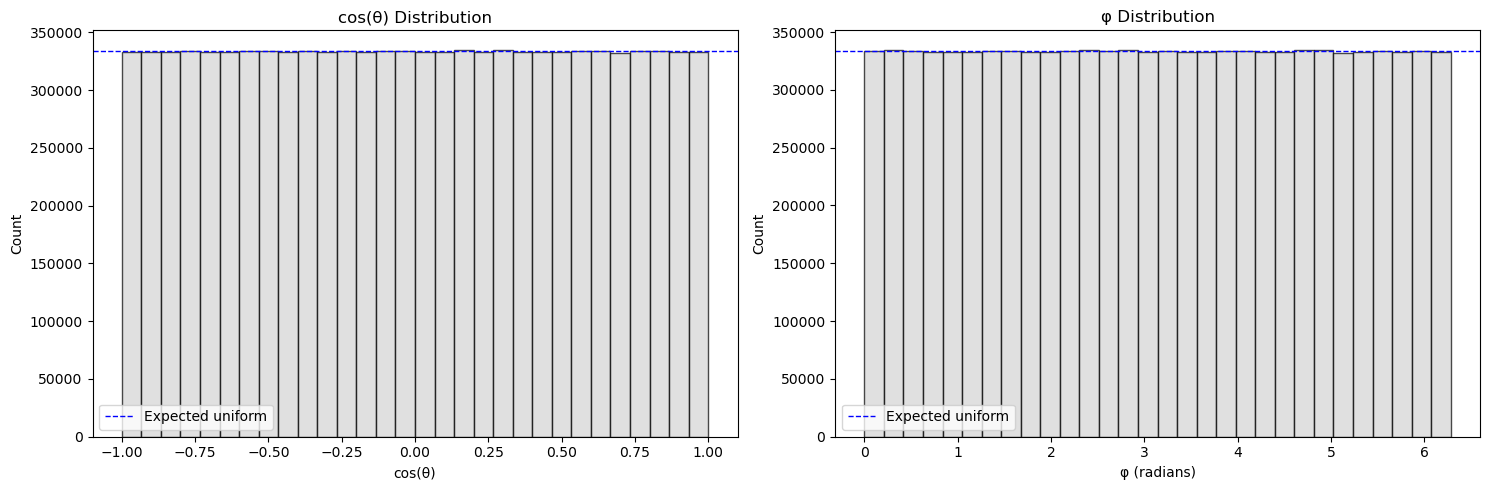

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- cos(theta) histogram ---
counts_costheta, bin_edges = np.histogram(beam_results["Daughter z"], bins=30, range=(-1, 1))
axes[0].hist(beam_results["Daughter z"], bins=30, range=(-1, 1), alpha=0.7, edgecolor='black', color="lightgray")
axes[0].axhline(Config["particle_count"]/30, color='b', linewidth=1, linestyle='--', label='Expected uniform')
axes[0].set_xlabel('cos(θ)')
axes[0].set_ylabel('Count')
axes[0].set_title('cos(θ) Distribution')
axes[0].legend()

# Chi-squared test for cos(theta) - AI generated
N_costheta = counts_costheta.sum()
k_costheta = len(counts_costheta)
E_costheta = N_costheta / k_costheta
chi2_costheta = np.sum((counts_costheta - E_costheta)**2 / E_costheta)
dof_costheta = k_costheta - 1
p_costheta = 1 - chi2.cdf(chi2_costheta, dof_costheta)

print("=" * 60)
print("cos(θ) Distribution - Chi-squared Test")
print("=" * 60)
print(f"χ² statistic: {chi2_costheta:.4f}")
print(f"Degrees of freedom: {dof_costheta}")
print(f"p-value: {p_costheta:.6f}")
print(f"Expected χ² mean (theory): {dof_costheta:.1f}")
print(f"Expected χ² std (theory): {np.sqrt(2*dof_costheta):.2f}")
print(f"Interpretation: {'UNIFORM' if p_costheta > 0.05 else 'DEVIATES from uniform'}")
print()

# --- phi histogram ---
counts_phi, bin_edges = np.histogram(beam_results["phi"], bins=30, range=(0, 2*np.pi))
axes[1].hist(beam_results["phi"], bins=30, range=(0, 2*np.pi), alpha=0.7, edgecolor='black', color="lightgray")
axes[1].axhline(Config["particle_count"]/30, color='b', linewidth=1, linestyle='--', label='Expected uniform')
axes[1].set_xlabel('φ (radians)')
axes[1].set_ylabel('Count')
axes[1].set_title('φ Distribution')
axes[1].legend()

# Chi-squared test for phi - AI generated
N_phi = counts_phi.sum()
k_phi = len(counts_phi)
E_phi = N_phi / k_phi
chi2_phi = np.sum((counts_phi - E_phi)**2 / E_phi)
dof_phi = k_phi - 1
p_phi = 1 - chi2.cdf(chi2_phi, dof_phi)

print("=" * 60)
print("φ Distribution - Chi-squared Test")
print("=" * 60)
print(f"χ² statistic: {chi2_phi:.4f}")
print(f"Degrees of freedom: {dof_phi}")
print(f"p-value: {p_phi:.6f}")
print(f"Expected χ² mean (theory): {dof_phi:.1f}")
print(f"Expected χ² std (theory): {np.sqrt(2*dof_phi):.2f}")
print(f"Interpretation: {'UNIFORM' if p_phi > 0.05 else 'DEVIATES from uniform'}")
print()

plt.tight_layout()
plt.show()


## Detector Measurement Graphs: $\:$ Hit Coords | x/y Hit Dists. | n_hits Histogram
---
This section plots all smeared hits into scatter plots for each detector. These are each accompanied by a pair of histograms showing the distribution of hits on the x and y axis. Additionally, histograms describing how many detectors each particle hit were plotted, one including `n_hits = 0` and one excluding it. <br><br>
Perplexity Research was used to generate these scatter plots. A copy-paste of the output from `hit_results.head()` was fed alongside the prompt so that it knew what the data format was. After that, the plots were hand-adjusted for presentation.<br>
Prompt: "Using the data format from 'hit_results' above, generate a 2x2 plt subplot that plots separate scatter plots according to the 'first_detector_idx' column. Add x and y axis histograms alongside each of these plots. Add padding between these subplots for appropriate spacing."


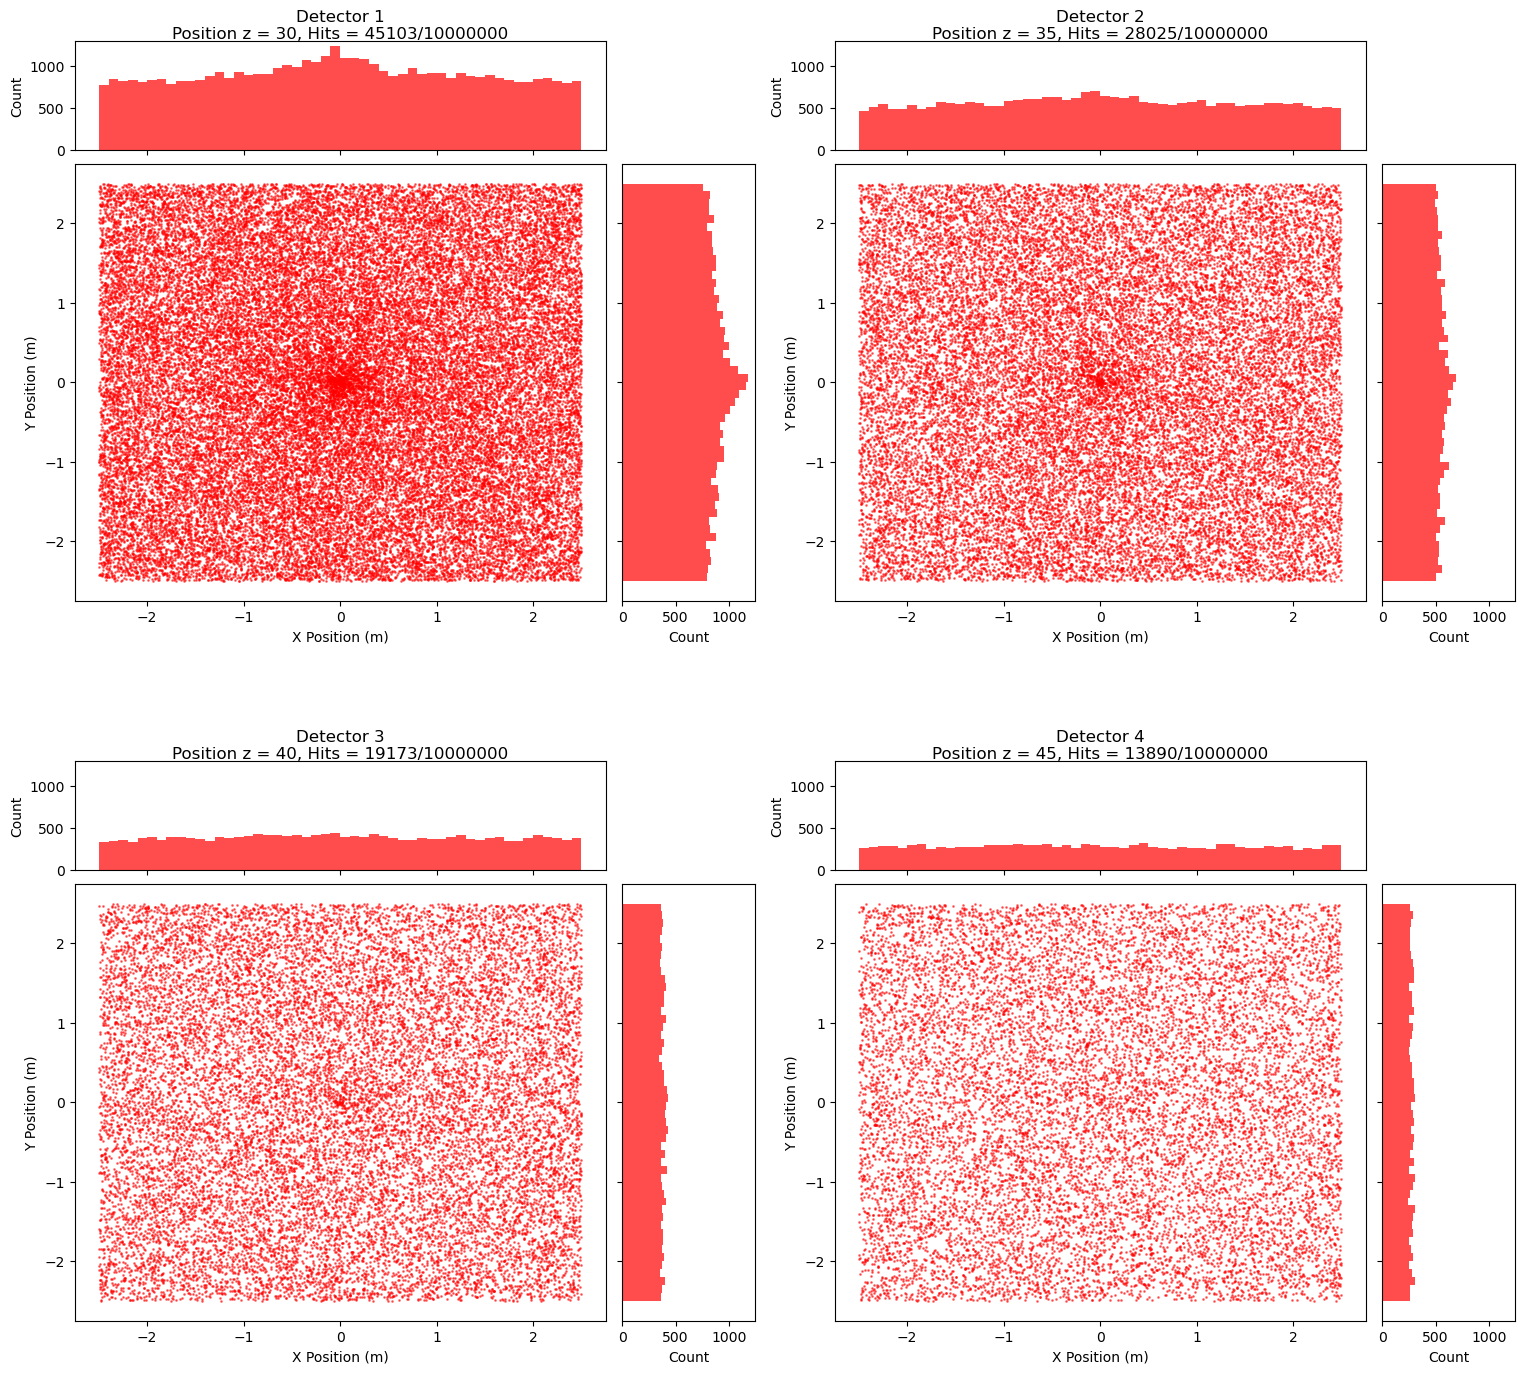

In [9]:
#AI generated and hand-adjusted. 
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()
num_detectors = len(Config["detector_positions"])

# Pre-compute global ranges for consistent scaling
all_x_positions = hit_results['smeared_x'].dropna().to_numpy()
all_y_positions = hit_results['smeared_y'].dropna().to_numpy()

# Define global histogram bins
x_bins = np.linspace(all_x_positions.min(), all_x_positions.max(), 51)
y_bins = np.linspace(all_y_positions.min(), all_y_positions.max(), 51)

# Pre-compute global max counts for consistent scaling
max_x_count = 0
max_y_count = 0

#Histogram scale finder
for idx in range(num_detectors):
    det_hits = hit_results[hit_results['detector'] == idx]
    smeared = det_hits[['smeared_x', 'smeared_y']].dropna().to_numpy()
    
    if smeared.size > 0 and smeared.ndim == 2:
        n_x, _ = np.histogram(smeared[:, 0], bins=x_bins)
        n_y, _ = np.histogram(smeared[:, 1], bins=y_bins)
        max_x_count = max(max_x_count, n_x.max())
        max_y_count = max(max_y_count, n_y.max())

# Scale with 5% padding
max_x_count *= 1.05
max_y_count *= 1.05

# Main plotting loop
for idx in range(num_detectors):
    axes[idx].remove()
    gs_main = fig.add_gridspec(2, 2, left=0.1 if idx % 2 == 0 else 0.575,
                               right=0.525 if idx % 2 == 0 else 1.0,
                               top=0.9 if idx < 2 else 0.45,
                               bottom=0.55 if idx < 2 else 0.1,
                               hspace=0.05, wspace=0.05,
                               width_ratios=[4, 1], height_ratios=[1, 4])
    ax_main = fig.add_subplot(gs_main[1, 0])
    ax_top = fig.add_subplot(gs_main[0, 0], sharex=ax_main)
    ax_right = fig.add_subplot(gs_main[1, 1], sharey=ax_main)

    # Get data for detector idx
    det_hits = hit_results[hit_results['detector'] == idx]
    smeared = det_hits[['smeared_x', 'smeared_y']].dropna().to_numpy()

    # Main scatter plot
    if smeared.size > 0 and smeared.ndim == 2:
        ax_main.scatter(smeared[:,0], smeared[:,1], s=1, alpha=0.5, color='red')
    ax_main.set_xlabel('X Position (m)')
    ax_main.set_ylabel('Y Position (m)')
    ax_main.set_title(f'Detector {idx+1}\nPosition z = {Config["detector_positions"][idx]}, Hits = {len(smeared)}/{Config["particle_count"]}', pad=90)

    # X distribution - use global max count
    if smeared.size > 0 and smeared.ndim == 2:
        ax_top.hist(smeared[:,0], bins=x_bins, color='red', alpha=0.7)
    ax_top.set_ylim(0, max_x_count)
    ax_top.tick_params(labelbottom=False)
    ax_top.set_ylabel('Count')

    # Y distribution - use global max count
    if smeared.size > 0 and smeared.ndim == 2:
        ax_right.hist(smeared[:,1], bins=y_bins, orientation='horizontal', color='red', alpha=0.7)
    ax_right.set_xlim(0, max_y_count)
    ax_right.tick_params(labelleft=False)
    ax_right.set_xlabel('Count')

plt.show()


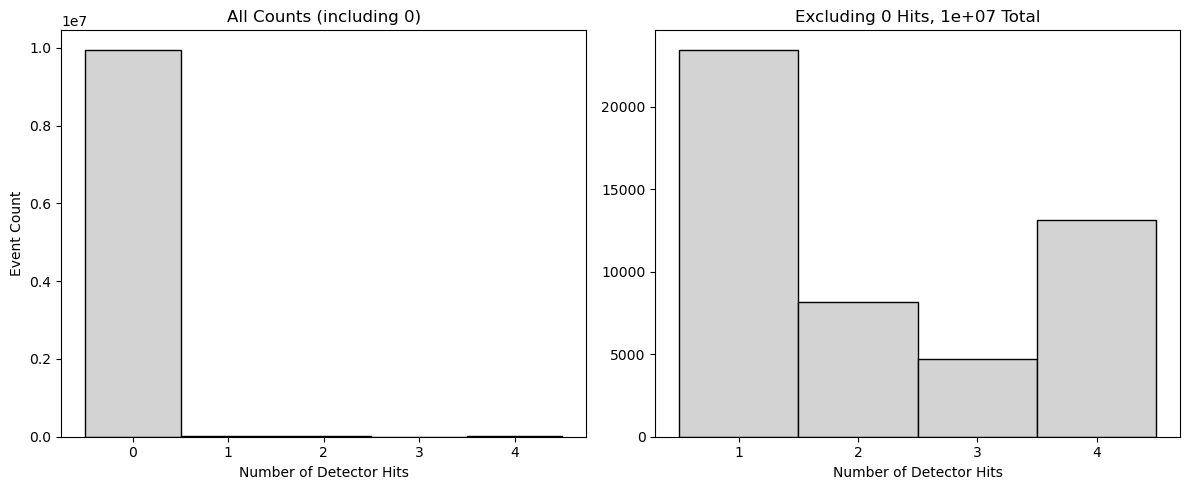

In [10]:
#Particle n_hit Histograms.
n_detectors = len(Config["detector_positions"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Plot including n_hits=0
bins_left = np.arange(-0.5, n_detectors + 1.5, 1)
axes[0].hist(beam_results["n hits"], bins=bins_left, edgecolor='black',color="lightgray")
axes[0].set_xlabel('Number of Detector Hits')
axes[0].set_ylabel('Event Count')
axes[0].set_title('All Counts (including 0)')
axes[0].set_xticks(np.arange(0, n_detectors + 1, 1))

#Plot excluding n_hits=0
hits_nonzero = beam_results[beam_results["n hits"] > 0]["n hits"]
bins_right = np.arange(0.5, n_detectors + 1.5, 1)
axes[1].hist(hits_nonzero, bins=bins_right, edgecolor='black',color="lightgray")
axes[1].set_xlabel('Number of Detector Hits')
axes[1].set_title(f'Excluding 0 Hits, {Config["particle_count"]:.3g} Total')
axes[1].set_xticks(np.arange(1, n_detectors + 1, 1))

plt.tight_layout()
plt.show()

## Validation of Detector Smear
---
This section validates simulated detector smear effects by comparing the smear distributions to expectations. Since Gaussian smear was used, the magnitude of smear $r$ is expected to follow a Gaussian PDF centered around 0, whilst the angle of smear $\theta$ is expected to be uniform.  

In [11]:
smeared_distances = []
smeared_angles = []

#Calculate smear
for idx, row in hit_results.iterrows():
    dx, dy = row["smeared_x"]-row["unsmeared_x"], row["smeared_y"]-row["unsmeared_y"]
    r = np.sqrt(dx**2 + dy**2)
    theta = np.arctan2(dy, dx)
    #Find whether r should be positive or negative, constrain theta to (0,pi] 
    if theta < 0:
        r *= -1
        theta *=-1
    
    smeared_distances.append(r)           
    smeared_angles.append(theta)

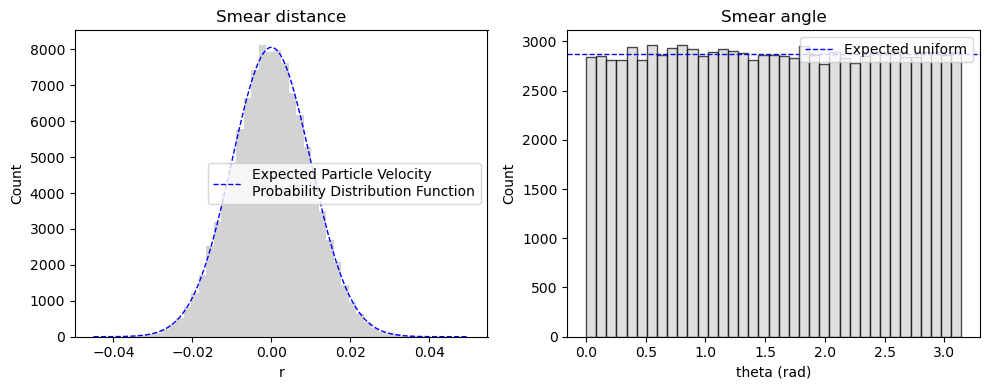

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

#Use PDF defined in Validation of Beam Particle Distribution
gauss_range = np.linspace(min(smeared_distances),max(smeared_distances), 1000)
gauss_pdf_values = [gaussian_pdf(val, mu=0, sigma=Config["detector_smear"]) for val in gauss_range]

counts0, bins_edges0, patches0 = ax1.hist(smeared_distances, bins=50, color="lightgray")
actual_bin_width0 = bins_edges0[1] - bins_edges0[0]
scaled_gauss_pdf = np.array(gauss_pdf_values) * len(smeared_distances) * actual_bin_width0
ax1.plot(gauss_range, scaled_gauss_pdf, "--b", linewidth=1, label='Expected Particle Velocity \nProbability Distribution Function')
ax1.set_title('Smear distance')
ax1.set_xlabel('r')
ax1.set_ylabel('Count')
ax1.legend()

bincount = 37
ax2.hist(smeared_angles,bins = bincount, range = (0, np.pi), alpha = 0.7, edgecolor='black',color="lightgray")
ax2.axhline(len(hit_results)/bincount, color='b', linewidth = 1, linestyle='--', label='Expected uniform')
ax2.set_title('Smear angle')
ax2.set_ylabel('Count')
ax2.set_xlabel('theta (rad)')
ax2.legend()

fig.tight_layout()
plt.show()


## Validating Monte Carlo hits using an Analytic Model, solved Numerically
---
This section validates the overall simulation by deriving and performing an independant analytical calculation of detector hit probabilities. This is used to guard against systematic errors such as potential double counting, non-isotropic particle generation, etc. <br><br>
Perplexity Research was used to generate the integration code. <br>
Prompt: "Using the given formula ($P_{hit}$), generate code to integrate between 0 and z_det. Please include safeguards for numerical stability and accuracy".

To verify that the Monte Carlo simulation yields the correct result, we employ an alternative method to find the probabilistic number of hits on a detector. The aim of this is to find the likelihood for a particle, with random velocity ($v$) and decay times ($t$) (as per the problem), to hit a detector at position $z_{det}$.<br>
1. First, we need to find the probability distribution function for decay positions, denoted as $f_z(z)$. This is done by finding the product of the independent distributions for $v$ and $t$. The working for this is written in the *Validation of Beam Particle Distribution* section.

2. Then, the subtended solid angle of the square detector at distance $\Delta = z_{det} - z$ is computed. This is then divided by $4\pi$ (the surface area of a unit sphere) to find the geometric hit probability ($P_{\text{geom}}$) at $z$.

3. The decay position PDF, $f_z(z)$, is then convolved with $P_{\text{geom}}$  over the possible range for detection, $0 \leq z \leq z_\text{det}$. This yields a double integral in $v$ and $z$, expressed in closed form.

4. Since this final form does not have any closed-form solutions, `scipy`'s adaptive quadrature is used to yield a solution.

**Finding the PDF for decay position**<br>
As derived in *Validation of Beam Particle Distribution*,
> $\displaystyle f_z(z) = \int^\infty_{0}\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(v-\mu)^2}{2\sigma^2}} \frac{1}{\tau v}e^{-\frac{z}{v\tau}} dv$

**Finding the Solid Angle hit probability for a given $z$** <br>
Since the daughter particle is emitted isotropically, the probability it hits a square detector of half-sides $(a,a)$ is equal to the ratio of the solid angle subtended by the detector to the total surface area of the sphere. At distance $\Delta = z_{det} - z$, the solid angle is:
> $\displaystyle \Omega(\Delta) = 4\arctan(\frac{a^2}{\Delta \sqrt{\Delta^2 + 2a^2}}) \implies P_{\text{geom}}(z) = \frac{\Omega(\Delta)}{4\pi} = \frac{1}{\pi} \arctan(\frac{a^2}{\Delta \sqrt{\Delta^2 + 2a^2}}) $

**Total Detection Probability**<br>
The overall probability that a particle is detected is found from the convolution of the decay position PDF with the geometric hit probability. Note that only decays upstream of the detector ($0 \leq z \leq z_\text{det}$) can be observed.
>$\displaystyle P_\text{hit} = \int^{z_\text{det}}_0 f_z(z) P_\text{geom}(z) dz = \int^{z_\text{det}}_0 \left[\int^\infty_{0}\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(v-\mu)^2}{2\sigma^2}} \frac{1}{\tau v}e^{-\frac{z}{v\tau}} dv \right]\frac{1}{\pi} \arctan(\frac{a^2}{(z_\text{det} - z) \sqrt{(z_\text{det} - z)^2 + 2a^2}}) dz $

**Computing the integral** <br>
Lastly, as the above double integral has no closed-form solution, a numerical method was used to calculate a final probability. This can then be compared to the results obtained through the monte-carlo simulation. The code below was AI generated and then adapted to specific variables. In this, several practical adjustments were made to ensure stability and accuracy:
- Instead of integrating from $0$ to $\infty$ in the velocity integral, the bounds were changed to $\mu \pm 5\sigma$, as regions beyond that would contribute negligibly and waste computation time.
- Similarly, the $v \to 0 $ singularity - which arises from the $\frac{1}{v}$ factor - is avoided by setting a small lower bound in case $\mu - 5\sigma$ extends beyond $0$.
- The position integral was split between two intervals: one covering most of the range, and one covering the near-$z_\text{det}$ zone, as the latter has a rapidly changing solid angle. This helps the integrator handle sharp changes in the integrand.

In [13]:
#AI Generated to solve the above integral
chosen_detector_index = 0 #choose from detector_positions
z_det = Config["detector_positions"][chosen_detector_index]

# Effective v-integration limits
v_min = max(1e-6, Config["mean_beam_velocity"] - 5*Config["std_beam_velocity"])
v_max = Config["mean_beam_velocity"] + 5*Config["std_beam_velocity"]

def Omega(delta):
    a = Config["detector_side_length"]  
    return np.arctan(a*a / (delta * np.sqrt(delta*delta + 2*a*a)))

def inner_v_integral(z):
    """Integrate over v in [v_min,v_max], where the Gaussian is non-negligible."""
    def integrand_v(v):
        fv        = np.exp(-0.5*((v-Config["mean_beam_velocity"])/Config["std_beam_velocity"])**2)
        fv       /= (Config["std_beam_velocity"] * np.sqrt(2*np.pi))
        ft_over_v = (1.0/(Config["mean_lifetime"]*v)) * np.exp(-z/(v*Config["mean_lifetime"]))
        return fv * ft_over_v

    val, err = integrate.quad(integrand_v, v_min, v_max, limit=200)
    return val

def integrand_z(z, z_det = Config["detector_positions"][chosen_detector_index]):
    delta  = z_det - z
    p_geom = Omega(delta) / np.pi
    return inner_v_integral(z) * p_geom

# Split z-integration to avoid singular geometry at z→z_det
P1, e1 = integrate.quad(integrand_z, 0, z_det-1e-3, args=(z_det,), limit=200)
P2, e2 = integrate.quad(integrand_z, z_det-1e-3, z_det, args=(z_det,), limit=200)
P_hit = P1 + P2
err   = e1 + e2

print(f"P_hit = {P_hit:.6e} ± {err:.1e}")

P_hit = 4.516421e-03 ± 1.2e-08


In [14]:
monte_probability = len(hit_results[hit_results["detector"]==chosen_detector_index])/Config["particle_count"]
monte_uncertainty = np.sqrt(monte_probability * (1 - monte_probability) / Config["particle_count"]) #Standard error (binomial uncertainty)
print(f"The Monte Carlo simulation predicts a hit probability of {monte_probability:.3g} ± {monte_uncertainty:.1g} for detector {chosen_detector_index+1}.")
print(f"Numerical evaluation of the respective analytic expression yielded a hit probability of {P_hit:.3g} (with negligible numerical uncertainty).")
print(f"The Monte Carlo prediction deviates from the numerically evaluated analytic value by {(P_hit - monte_probability)/monte_uncertainty:.3g} standard deviations, indicating excellent agreement between methods. ")

The Monte Carlo simulation predicts a hit probability of 0.00451 ± 2e-05 for detector 1.
Numerical evaluation of the respective analytic expression yielded a hit probability of 0.00452 (with negligible numerical uncertainty).
The Monte Carlo prediction deviates from the numerically evaluated analytic value by 0.289 standard deviations, indicating excellent agreement between methods. 


## Extension part 1: Decay Position Reconstruction using Smeared Data.
---
This section performs a linear regression on the hit coordinates of every particle that hits all 4 detectors. This is done to reconstruct the decay position, as one would in an experiment. This is done with smeared and unsmeared data, so a comparison of the effects of the smear on experimental results can be made. <br><br>
Perplexity Research was used to generate the linear regression. <br>
Prompt: "I have grouped my 'hit_results' dataframe by particle id using 'hit_results['particle_id'] = (hit_results['detector'].diff() <= 0).cumsum()'. Please apply a linear regression on all particles with 4 sets of smeared hit coordinates. I want this to return the z-coordinate where the resulting line intersects x=y=0, with a 0.1 radial tolerance. Please calculate regression error, and append both this and the z-coord to 'decay_z_smeared_reconstruct' and 'decay_z_smeared_errors'. Repeat this on the unsmeared data, omitting error calculations."

In [15]:
#Initialize storage
decay_z_smeared_reconstruct = []
decay_z_smeared_errors = []
decay_z_unsmeared_reconstruct = []

#Group by particle
hit_results['particle_id'] = (hit_results['detector'].diff() <= 0).cumsum()

#Process each particle that has exactly 4 hits - AI generated
for particle_id, group in hit_results.groupby('particle_id'):
    if len(group) != 4:
        continue
    
    #Get detector z positions
    detectors = group['detector'].values
    z_coords = np.array([Config["detector_positions"][int(d)] for d in detectors])
    
    #Get hit coordinates
    x_smeared = group['smeared_x'].values
    y_smeared = group['smeared_y'].values
    x_unsmeared = group['unsmeared_x'].values
    y_unsmeared = group['unsmeared_y'].values
    
    # === SMEARED RECONSTRUCTION WITH ERRORS === 
    fit_x_s = linregress(z_coords, x_smeared)
    fit_y_s = linregress(z_coords, y_smeared)
    
    # Calculate z_min
    numerator_s = fit_x_s.slope * fit_x_s.intercept + fit_y_s.slope * fit_y_s.intercept
    denominator_s = fit_x_s.slope**2 + fit_y_s.slope**2
    z_min_s = -numerator_s / denominator_s
    
    # Error propagation
    dz_dsx = -(fit_x_s.intercept * denominator_s - 2 * fit_x_s.slope * numerator_s) / (denominator_s**2)
    dz_dix = -fit_x_s.slope / denominator_s
    dz_dsy = -(fit_y_s.intercept * denominator_s - 2 * fit_y_s.slope * numerator_s) / (denominator_s**2)
    dz_diy = -fit_y_s.slope / denominator_s
    
    var_from_fits = (
        (dz_dsx * fit_x_s.stderr)**2 +
        (dz_dix * fit_x_s.intercept_stderr)**2 +
        (dz_dsy * fit_y_s.stderr)**2 +
        (dz_diy * fit_y_s.intercept_stderr)**2
    )
    
    x_pred_s = fit_x_s.slope * z_coords + fit_x_s.intercept
    y_pred_s = fit_y_s.slope * z_coords + fit_y_s.intercept
    sigma_res_x = np.sqrt(np.sum((x_smeared - x_pred_s)**2) / 2)
    sigma_res_y = np.sqrt(np.sum((y_smeared - y_pred_s)**2) / 2)
    
    var_from_residuals = (
        (dz_dsx * sigma_res_x)**2 +
        (dz_dix * sigma_res_x)**2 +
        (dz_dsy * sigma_res_y)**2 +
        (dz_diy * sigma_res_y)**2
    ) / 4
    
    z_min_error = np.sqrt(var_from_fits + var_from_residuals)
    
    # Quality cuts for smeared
    if -5 < z_min_s < min(Config["detector_positions"]):
        x_at_min_s = fit_x_s.slope * z_min_s + fit_x_s.intercept
        y_at_min_s = fit_y_s.slope * z_min_s + fit_y_s.intercept
        distance_at_min_s = np.sqrt(x_at_min_s**2 + y_at_min_s**2)
        
        if distance_at_min_s < 0.1:
            decay_z_smeared_reconstruct.append(z_min_s)
            decay_z_smeared_errors.append(z_min_error)
    
    # === UNSMEARED RECONSTRUCTION (NO ERRORS) ===
    fit_x_u = linregress(z_coords, x_unsmeared)
    fit_y_u = linregress(z_coords, y_unsmeared)
    
    # Calculate z_min
    numerator_u = fit_x_u.slope * fit_x_u.intercept + fit_y_u.slope * fit_y_u.intercept
    denominator_u = fit_x_u.slope**2 + fit_y_u.slope**2
    z_min_u = -numerator_u / denominator_u
    
    # Quality cuts for unsmeared
    if 0 < z_min_u < min(Config["detector_positions"]):
        x_at_min_u = fit_x_u.slope * z_min_u + fit_x_u.intercept
        y_at_min_u = fit_y_u.slope * z_min_u + fit_y_u.intercept
        distance_at_min_u = np.sqrt(x_at_min_u**2 + y_at_min_u**2)
        
        if distance_at_min_u < 0.01:  # stricter threshold
            decay_z_unsmeared_reconstruct.append(z_min_u)

# Convert to arrays
decay_z_smeared_reconstruct = np.array(decay_z_smeared_reconstruct)
decay_z_smeared_errors = np.array(decay_z_smeared_errors)
decay_z_unsmeared_reconstruct = np.array(decay_z_unsmeared_reconstruct)

print(f"Smeared decays: {len(decay_z_smeared_reconstruct)}")
print(f"Unsmeared decays: {len(decay_z_unsmeared_reconstruct)}")
print(f"Mean smeared error: {np.mean(decay_z_smeared_errors):.4f}")

Smeared decays: 13090
Unsmeared decays: 13104
Mean smeared error: 0.8515


In [16]:
#Key parameter for the rest of the analysis. More bins makes for better geometric normalization and better fitting, 
# but introduces larger poisson errors
bin_count = 300

Theoretical: mean=4.923035
Smeared: mean=6.690876
Bias: 1.767841


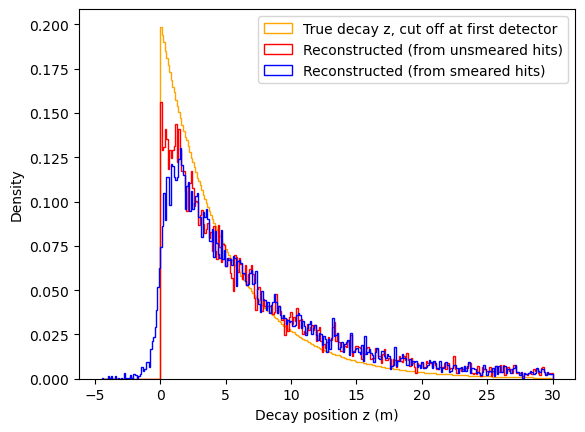

In [17]:
decay_z_theoretical = beam_results[beam_results["Decay Position"] < Config["detector_positions"][0]]["Decay Position"]

#AI Generated to ensure there is a bin that starts at z=0
k = np.searchsorted(np.linspace(min(decay_z_smeared_reconstruct), 30, bin_count + 1), 0)
shared_bins = np.concatenate([ np.linspace(min(decay_z_smeared_reconstruct), 0, k, endpoint=False), np.linspace(0, Config["detector_positions"][0], bin_count - k + 1) ])

alpha = 1.0
fig, ax = plt.subplots()
ax.hist(decay_z_theoretical,color="orange", histtype='step',bins=shared_bins, alpha=alpha, label='True decay z, cut off at first detector',density=True)
ax.hist(decay_z_unsmeared_reconstruct,color="red", histtype='step',bins = shared_bins, alpha = alpha, label = 'Reconstructed (from unsmeared hits)', density = True)
ax.hist(decay_z_smeared_reconstruct,color="blue", histtype='step', bins=shared_bins, alpha=alpha, label='Reconstructed (from smeared hits)', density = True)
ax.set_xlabel('Decay position z (m)')
ax.set_ylabel('Density')
ax.legend()

# Quantify bias and resolution
print(f"Theoretical: mean={np.mean(decay_z_theoretical):.6f}")
print(f"Smeared: mean={np.mean(decay_z_smeared_reconstruct):.6f}")
print(f"Bias: {np.mean(decay_z_smeared_reconstruct) - np.mean(decay_z_theoretical):.6f}")


## Extension part 2: Normalization of Measurements using Solid Angle Geometry.
---
The previous section saw a clear bias between reconstructed distributions and the original data. This is because of the underlying geometry: a particle is more likely to be measured if it is nearer to the detector, so measurement data will overrepresent particles with nearer decay positions. <br>
This section rectifies this by calculating and applying a bin-by-bin geometrical normalisation, calculated from the $P_{geom}$ formula defined in the *Validating Monte Carlo hits using an Analytic Model, solved Numerically* section.<br>
Additionally, squared bin errors are calculated as the sum of the squares of regression and poisson (counting) errors (see report). This is done before the normalisation, such that the errors can also be scaled.<br><br>
Perplexity Research was used to generate the $P_{geom}$ function, from a latex-equation input.

In [18]:
# Create histogram
smeared_counts, bin_edges = np.histogram(decay_z_smeared_reconstruct, bins=shared_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate errors
smeared_errors = np.zeros_like(smeared_counts, dtype=float)
bin_indices = np.digitize(decay_z_smeared_reconstruct, bin_edges) - 1

for i_bin in range(len(smeared_counts)):
    mask = (bin_indices == i_bin)
    if np.any(mask):
        regression_error_sq = np.sum(decay_z_smeared_errors[mask]**2)
        poisson_error_sq = smeared_counts[i_bin]
        smeared_errors[i_bin] = np.sqrt(regression_error_sq + poisson_error_sq)

In [19]:
#Use the solid angle hit probability defined under Validating Monte Carlo Simulation. AI generated from formula.
def p_geom(z, z_det, a):
    """
    z: scalar or array of decay positions
    z_det: position of detector
    a: half-side of square detector
    Returns:
        Geometric probability for decay at z to hit detector at z_det
        P = (1/pi) * arctan(a^2 / (Delta sqrt(Delta^2 + 2a^2)))
        P = 0 for z >= z_det (can only hit if before detector)
    """
    delta = z_det - z
    
    # Only allow for decays before the detector location
    argument = np.where(delta > 0, a**2 / (delta * np.sqrt(delta**2 + 2*a**2)), 0)
    P = (1 / np.pi) * np.arctan(argument)
    return np.where(delta > 0, P, 1)

#From above hist
bin_centers = 0.5 * (shared_bins[:-1] + shared_bins[1:])
binwidth = shared_bins[1]-shared_bins[0]

p_geom_values = p_geom(bin_centers, Config["detector_positions"][-1],Config["detector_side_length"])

#Correct counts and errors using geometric hit probability.
corrected_smeared_counts = smeared_counts/p_geom_values
corrected_smeared_errors = smeared_errors/p_geom_values
#Normalize counts and errors for density plots
corrected_smeared_counts, corrected_smeared_errors = (corrected_smeared_counts, corrected_smeared_errors)/ (np.sum(corrected_smeared_counts) * binwidth)

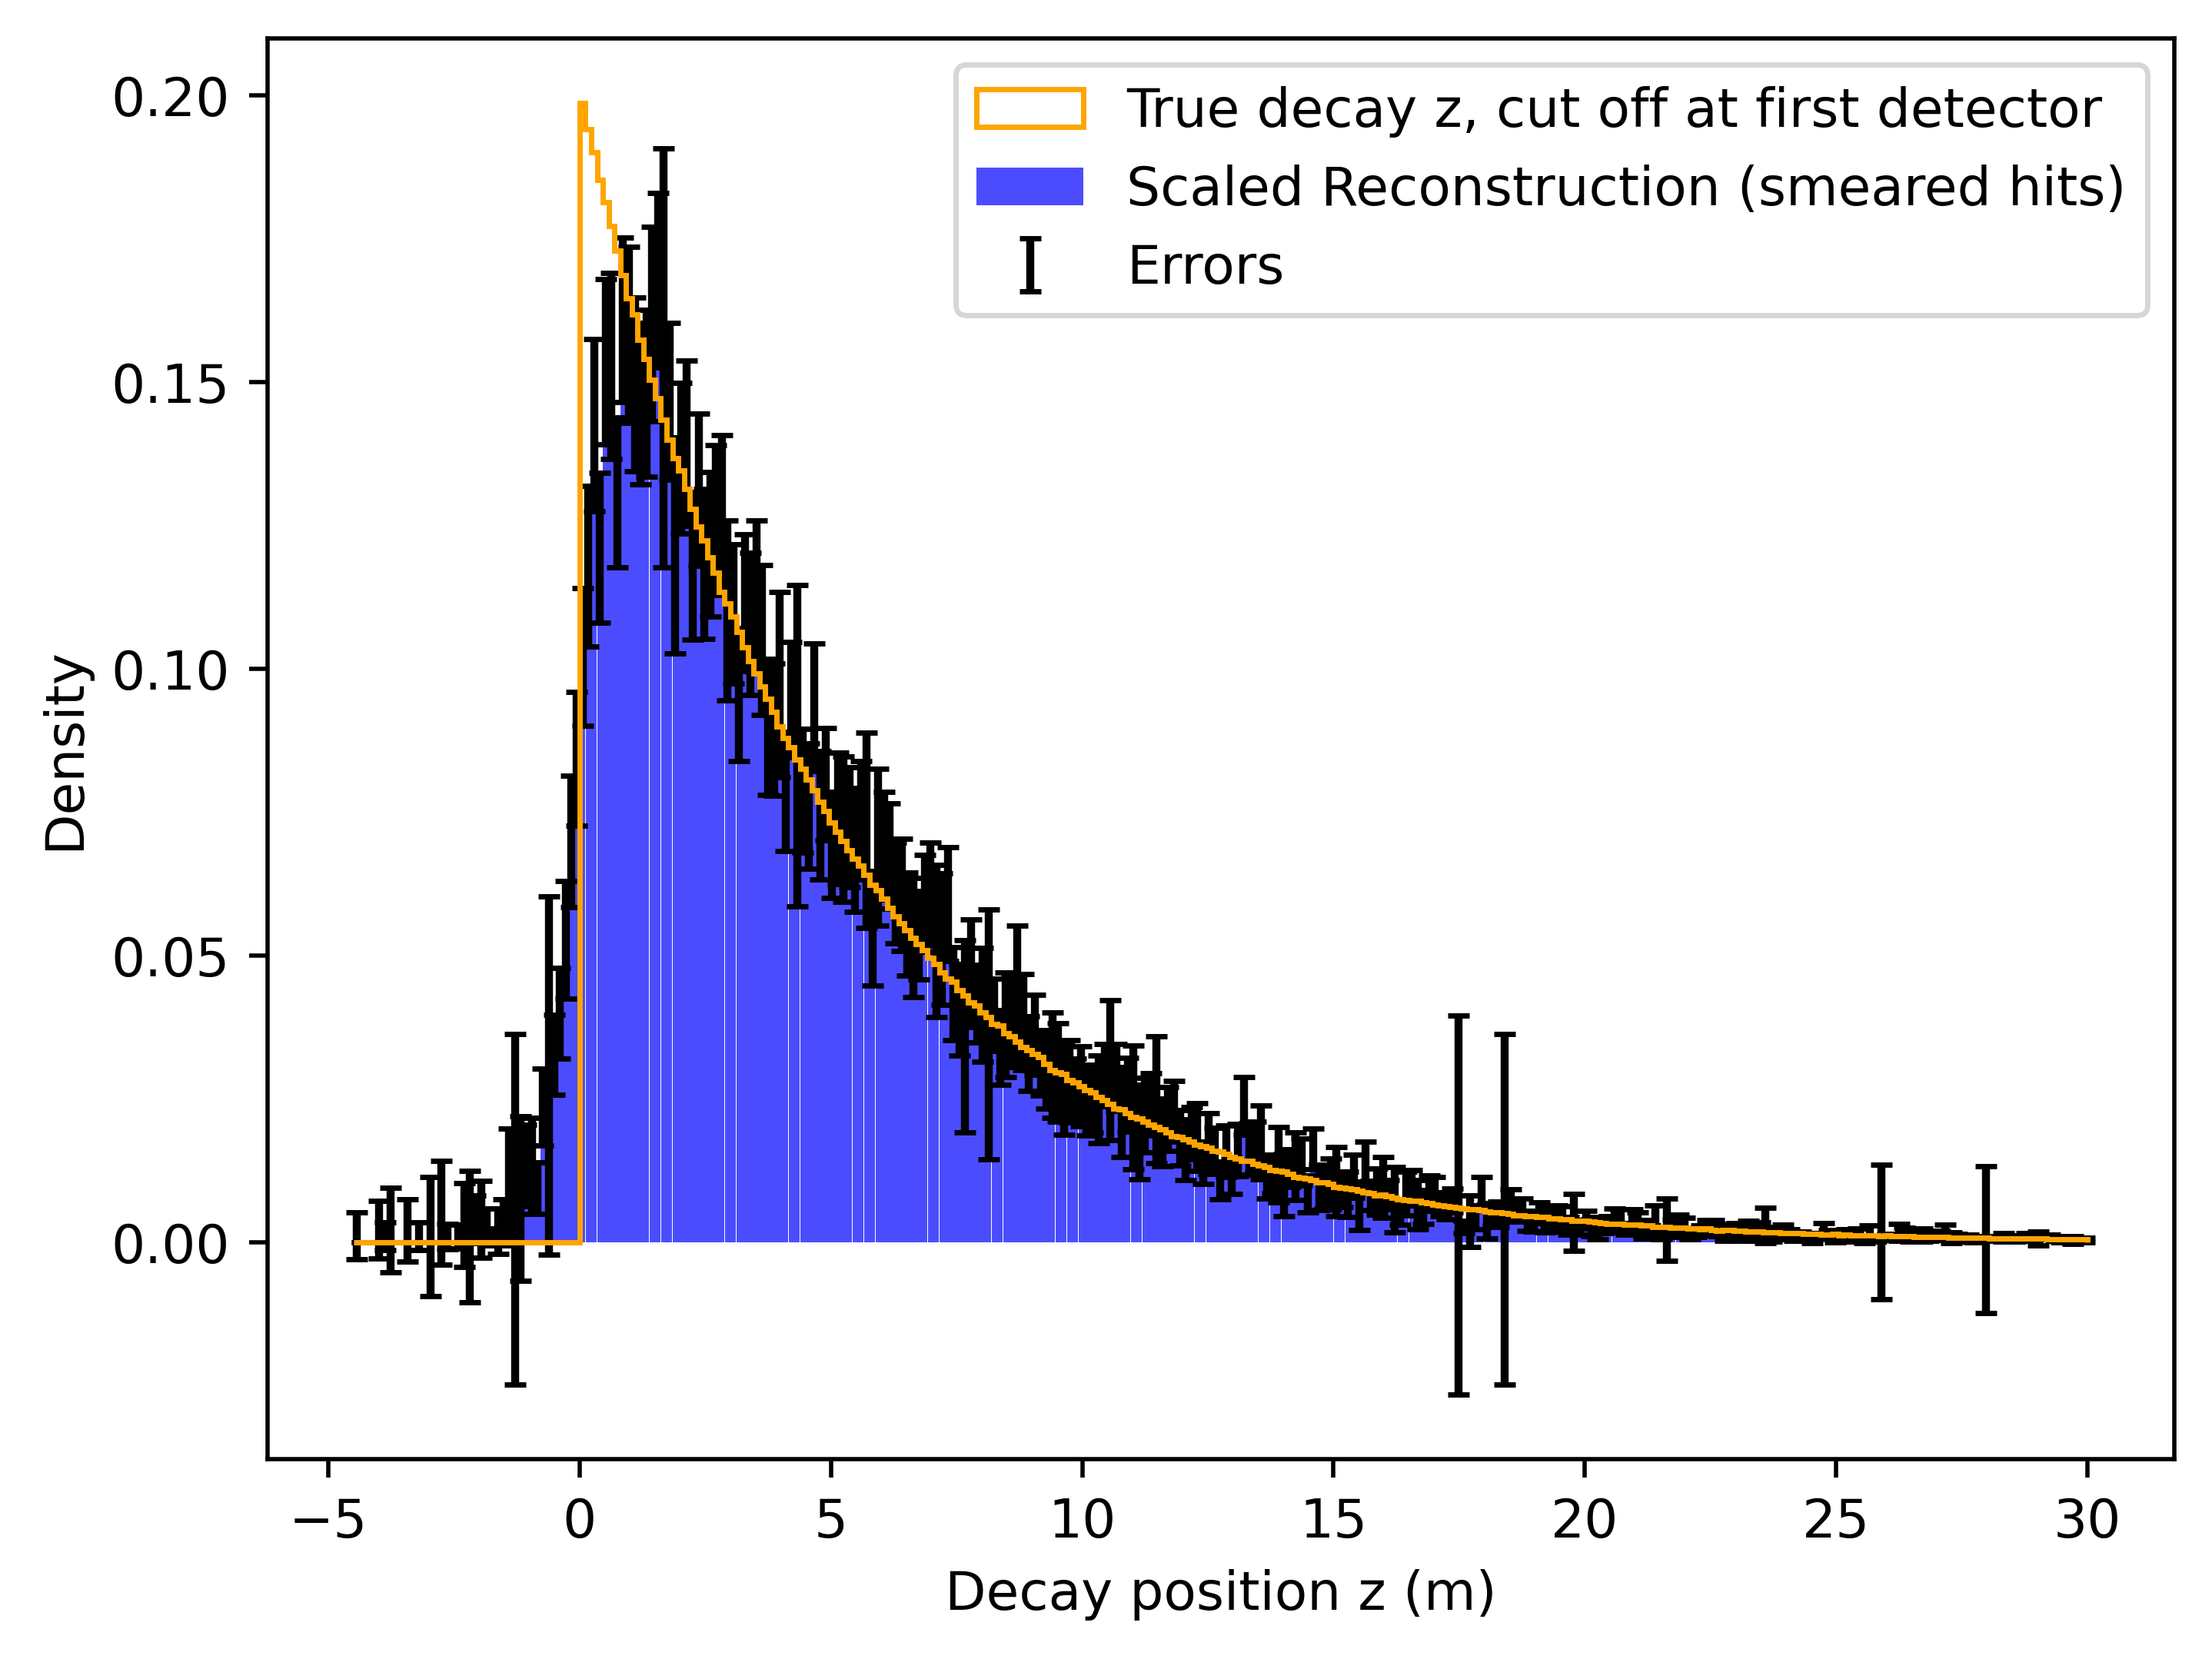

In [20]:
plt.figure(dpi=500)  #Higher DPI reduces rendering artifacts
plt.bar(bin_centers, corrected_smeared_counts, width=binwidth, align='center', alpha=0.7, label='Scaled Reconstruction (smeared hits)', color='blue', edgecolor='none')
plt.errorbar(bin_centers, corrected_smeared_counts, yerr=corrected_smeared_errors, fmt='none', ecolor='black', capsize=2, label='Errors')
plt.hist(decay_z_theoretical,color="orange", histtype='step',bins=shared_bins, alpha=alpha, label='True decay z, cut off at first detector',density=True)
plt.xlabel('Decay position z (m)')
plt.ylabel('Density')
plt.legend()
plt.show()

## Extension part 3: Fitting to find Lifetime.
---
This section fits the PDF of $z$, the decay position distribution, to the normalised measurements in order to find $\tau$. The PDF used is the same as defined in the *Validation of Beam Particle Distribution* section, where $z$ is found as the convolution of $v$ and $t$.<br>
This assumes knowledge of the mean beam velocity and its standard deviation, as otherwise fitting $\mu, \sigma,$ and $\tau$ simultaneously leads to degenerate results. All unphysical results due to smear are also masked. <br><br>
Perplexity Research was used to generate the fitting code.<br>
Prompt: "Generate code to fit tau using the formula provided [PDF of z]. Your inputs are binned normalised measurements (corrected_smeared_counts), the bin centers (bin_centers), and known parameters of mu and sigma for the fit. Generate plotting code comparing the fit to an error bar chart of this data, and a comparison table stating tau, its error, the relative error, and the number of standard deviations from the true value stored under Config["mean_lifetime"]."

In [21]:
# Keep only bins with z >= 0
valid_mask = bin_centers >= 0
bin_centers = bin_centers[valid_mask]
corrected_smeared_counts = corrected_smeared_counts[valid_mask]
corrected_smeared_errors = corrected_smeared_errors[valid_mask]

In [22]:
#AI Generated from conlvolution equation in Validating Monte Carlo hits using an Analytic Model, solved Numerically 
def f_z_model(z, mu, sigma, tau):
    """
    Compute f_z(z) by numerical integration over v.
    
    Integrand: (1/sqrt(2*pi*sigma^2)) * exp(-(v-mu)^2/(2*sigma^2)) 
               * (1/(tau*v)) * exp(-z/(v*tau))
    """
    def integrand(v, z, mu, sigma, tau):
        if v <= 0:
            return 0
        
        exponent_gaussian = -((v - mu)**2) / (2 * sigma**2)
        exponent_exponential = -z / (v * tau)
        
        # CAP the exponents at -700 BEFORE exp()
        # This prevents overflow while keeping math correct
        exponent_gaussian = np.maximum(exponent_gaussian, -700)
        exponent_exponential = np.maximum(exponent_exponential, -700)
        
        gaussian = (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(exponent_gaussian)
        exponential = (1.0 / (tau * v)) * np.exp(exponent_exponential)
        
        return gaussian * exponential
    
    result, _ = integrate.quad(integrand, 1e-6, max(10 * mu, 50), args=(z, mu, sigma, tau))
    return result

def f_z_array(z_array, mu, sigma, tau):
    """Vectorized computation for array of z values."""
    return np.array([f_z_model(z, mu, sigma, tau) for z in z_array])
    
mu_known = Config["mean_beam_velocity"]
sigma_known = Config["std_beam_velocity"]

def model(z, tau):
    return f_z_array(z, mu=mu_known, sigma=sigma_known, tau=tau)

mean_z = np.sum(bin_centers * corrected_smeared_counts) / np.sum(corrected_smeared_counts)
tau_guess = mean_z / mu_known

In [23]:
#Parametric fit for smeared hits
popt, pcov = curve_fit(model, bin_centers, corrected_smeared_counts, p0=[tau_guess], bounds=([tau_guess/10], [tau_guess*10]),sigma=corrected_smeared_errors,absolute_sigma=True)
tau_fit_smeared = popt[0] * 1000             #in ms
tau_err_smeared = np.sqrt(pcov[0, 0]) * 1000 #in ms
print("Using smeared data:")
print(f"τ = {tau_fit_smeared:.3g} ± {tau_err_smeared:.1g} ms")
print(f"Relative error: {tau_err_smeared/tau_fit_smeared:.1%}")

Using smeared data:
τ = 2.52 ± 0.02 ms
Relative error: 1.0%


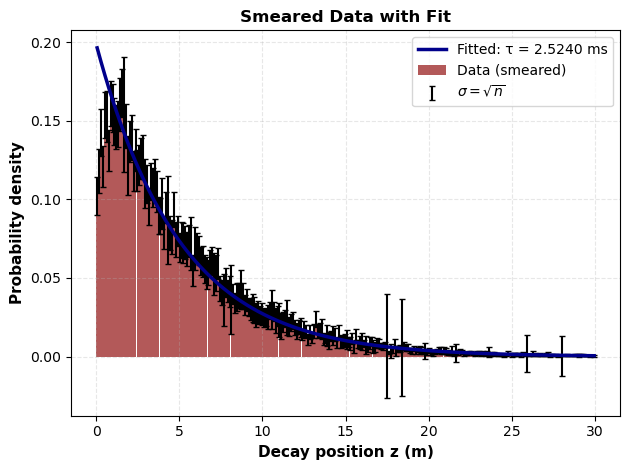


COMPARISON: UNSMEARED vs SMEARED

Metric                        Smeared             
----------------------------------------------------------------------
τ (ms)                        2.524001
τ error (ms)                  0.024975
Rel. error (%)                  0.99%
Std from True Lifetime          0.96


In [24]:
#AI generated plots
model_fit_smeared = f_z_array(bin_centers, mu=mu_known, sigma=sigma_known, tau=tau_fit_smeared/1000)

plt.bar(bin_centers, corrected_smeared_counts, width=binwidth, 
       alpha=0.65, color='darkred', label='Data (smeared)', edgecolor='none')
plt.errorbar(bin_centers, corrected_smeared_counts, yerr=corrected_smeared_errors, fmt='none', ecolor='black', capsize=2, label='$\sigma = \sqrt{n}$')
plt.plot(bin_centers, model_fit_smeared, 'darkblue', linewidth=2.5, 
        label=f'Fitted: τ = {tau_fit_smeared:.4f} ms')
plt.xlabel('Decay position z (m)', fontsize=11, fontweight='bold')
plt.ylabel('Probability density', fontsize=11, fontweight='bold')
plt.title('Smeared Data with Fit', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print comparison table
sigma_from_true_smeared = abs(tau_fit_smeared - Config["mean_lifetime"]*1000) / tau_err_smeared
print("\n" + "="*70)
print("COMPARISON: UNSMEARED vs SMEARED")
print("="*70)
print(f"\n{'Metric':<30}{'Smeared':<20}")
print("-"*70)
print(f"{'τ (ms)':<30}{tau_fit_smeared:.6f}")
print(f"{'τ error (ms)':<30}{tau_err_smeared:.6f}")
print(f"{'Rel. error (%)':<30}{tau_err_smeared/tau_fit_smeared*100:>6.2f}%")
print(f"{'Std from True Lifetime':<30}{sigma_from_true_smeared:>6.2f}")

## Parallel Processing time testing 
---
This final section tests the effects of varying the number of cores used in parallel processing on computation time. This uses 10 million particles by default, and tests the same 10 seed lists for each core count. This gives an average computation time, and a standard deviation. Results are plotted.<br><br>
Perplexity Research was used to fix memory issues in this loop. Its fix ensures that all results are completely cleared from memory before calculating the next batch. <br>
Prompt: "[Show code] This code crashes after 7-8 iterations. My browser closes citing memory overload. Could there be a memory leak? If so, generate code fixing this." 

In [4]:
#Input original simple loop code, AI generated fixes introduced due to memory overload and improper client cleanup.
from IPython.display import clear_output
import gc

meantimes = []
stdtimes = []
core_count = list(range(2,12,2))
particles = int(1e7)
reps = 10
seeds = [np.random.randint(0, 2**8-1, particles) for _ in range(reps)]
for Ncores in core_count: 
    chunksize = min(max(1, particles // (Ncores * 4)), 1000)
    cluster = ipp.Cluster(n=Ncores)
    cluster.start_and_connect_sync()
    rc = cluster.connect_client_sync()
    print(f"Testing with {Ncores} cores (chunksize={chunksize})")
    lview = rc.load_balanced_view()
    lview.block = False
    
    temptime = []
    for i in range(reps):                   
        print(f"Rep {i+1}/{reps}; core {Ncores}")
        s = time.time()
        configlist = [Config] * particles
        async_result = lview.map_async(compute_single_particle, configlist, seeds[i], chunksize=chunksize)
        
        # IMPROVED: Use wait() instead of polling progress
        async_result.wait()
        
        e = time.time()      
        temptime.append(e-s)
        
        # Explicit cleanup
        try:
            rc.purge_results('all')
            rc.purge_local_results('all')
        except:
            pass  # Ignore if already purged
        
        del async_result
        gc.collect()
    
    # CRITICAL: Proper shutdown sequence
    time.sleep(0.5)  # Allow graceful shutdown
    try:
        cluster.stop_cluster_sync()
    except:
        cluster.stop_cluster_sync(hub=True)  # Force kill if needed
    rc.close()
    time.sleep(1)  # Wait for ports to be released
    
    meantimes.append(np.mean(temptime))
    stdtimes.append(np.std(temptime))

Starting 2 engines with <class 'ipyparallel.cluster.launcher.LocalEngineSetLauncher'>


  0%|          | 0/2 [00:00<?, ?engine/s]

Testing with 2 cores (chunksize=1000)
Rep 1/10; core 2
Rep 2/10; core 2
Rep 3/10; core 2
Rep 4/10; core 2
Rep 5/10; core 2
Rep 6/10; core 2
Rep 7/10; core 2
Rep 8/10; core 2
Rep 9/10; core 2
Rep 10/10; core 2
Stopping controller
Output for ipcontroller-1764612600-oy5p-12684:
2025-12-01 18:44:56.716 [IPController] task::task 'b5d6aa05-ca1e8266430e609efac71e26_12684_99962' arrived on 0
2025-12-01 18:44:56.716 [IPController] task::task 'b5d6aa05-ca1e8266430e609efac71e26_12684_99960' finished on 0
2025-12-01 18:44:56.731 [IPController] task::task 'b5d6aa05-ca1e8266430e609efac71e26_12684_99963' arrived on 1
2025-12-01 18:44:56.732 [IPController] task::task 'b5d6aa05-ca1e8266430e609efac71e26_12684_99961' finished on 1
2025-12-01 18:44:56.747 [IPController] task::task 'b5d6aa05-ca1e8266430e609efac71e26_12684_99964' arrived on 0
2025-12-01 18:44:56.747 [IPController] task::task 'b5d6aa05-ca1e8266430e609efac71e26_12684_99962' finished on 0
2025-12-01 18:44:56.762 [IPController] task::task 'b5d6

  0%|          | 0/4 [00:00<?, ?engine/s]

Testing with 4 cores (chunksize=1000)
Rep 1/10; core 4
Rep 2/10; core 4
Rep 3/10; core 4
Rep 4/10; core 4
Rep 5/10; core 4
Rep 6/10; core 4
Rep 7/10; core 4
Rep 8/10; core 4
Rep 9/10; core 4
Rep 10/10; core 4
Stopping controller
Failed to remove C:\Users\Rapha\.ipython\profile_default\log\ipcontroller-1764614706-ktpr-12684.log: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\Rapha\\.ipython\\profile_default\\log\\ipcontroller-1764614706-ktpr-12684.log'
Output for ipcontroller-1764614706-ktpr-12684:
2025-12-01 19:07:40.291 [IPController] task::task '72984e0e-bcba5f9410748bd82a3c8704_12684_99963' arrived on 2
2025-12-01 19:07:40.291 [IPController] task::task '72984e0e-bcba5f9410748bd82a3c8704_12684_99959' finished on 2
2025-12-01 19:07:40.292 [IPController] task::task '72984e0e-bcba5f9410748bd82a3c8704_12684_99964' arrived on 0
2025-12-01 19:07:40.293 [IPController] task::task '72984e0e-bcba5f9410748bd82a3c8704_12684_99960' finish

...

Testing with 6 cores (chunksize=1000)
Rep 1/10; core 6
Rep 2/10; core 6
Rep 3/10; core 6
Rep 4/10; core 6
Rep 5/10; core 6
Rep 6/10; core 6
Rep 7/10; core 6
Rep 8/10; core 6
Rep 9/10; core 6
Rep 10/10; core 6
Stopping controller
Failed to remove C:\Users\Rapha\.ipython\profile_default\log\ipcontroller-1764616068-zrsx-12684.log: [WinError 2] The system cannot find the file specified: 'C:\\Users\\Rapha\\.ipython\\profile_default\\log\\ipcontroller-1764616068-zrsx-12684.log'
Output for ipcontroller-1764616068-zrsx-12684:
2025-12-01 19:27:28.299 [IPController] task::task '31e3a9ee-0b1c5d9cf9f9ed646a472e88_12684_99964' arrived on 5
2025-12-01 19:27:28.300 [IPController] task::task '31e3a9ee-0b1c5d9cf9f9ed646a472e88_12684_99960' finished on 5
2025-12-01 19:27:28.306 [IPController] task::task '31e3a9ee-0b1c5d9cf9f9ed646a472e88_12684_99965' arrived on 4
2025-12-01 19:27:28.307 [IPController] task::task '31e3a9ee-0b1c5d9cf9f9ed646a472e88_12684_99957' finished on 4
2025-12-01 19:27:28.313 [IPCon

  0%|          | 0/8 [00:00<?, ?engine/s]

Testing with 8 cores (chunksize=1000)
Rep 1/10; core 8
Rep 2/10; core 8
Rep 3/10; core 8
Rep 4/10; core 8
Rep 5/10; core 8
Rep 6/10; core 8
Rep 7/10; core 8
Rep 8/10; core 8
Rep 9/10; core 8
Rep 10/10; core 8
Stopping controller
Output for ipcontroller-1764617256-hfd6-12684:
2025-12-01 19:45:47.960 [IPController] task::task 'eb620438-f45cef695dd2403b6d0044b1_12684_99965' arrived on 4
2025-12-01 19:45:47.961 [IPController] task::task 'eb620438-f45cef695dd2403b6d0044b1_12684_99957' finished on 4
2025-12-01 19:45:47.980 [IPController] task::task 'eb620438-f45cef695dd2403b6d0044b1_12684_99966' arrived on 1
2025-12-01 19:45:47.981 [IPController] task::task 'eb620438-f45cef695dd2403b6d0044b1_12684_99959' finished on 1
2025-12-01 19:45:47.987 [IPController] task::task 'eb620438-f45cef695dd2403b6d0044b1_12684_99967' arrived on 2
2025-12-01 19:45:47.987 [IPController] task::task 'eb620438-f45cef695dd2403b6d0044b1_12684_99960' finished on 2
2025-12-01 19:45:47.991 [IPController] task::task 'eb62

  0%|          | 0/10 [00:00<?, ?engine/s]

Testing with 10 cores (chunksize=1000)
Rep 1/10; core 10
Rep 2/10; core 10
Rep 3/10; core 10
Rep 4/10; core 10
Rep 5/10; core 10
Rep 6/10; core 10
Rep 7/10; core 10
Rep 8/10; core 10
Rep 9/10; core 10
Rep 10/10; core 10
Stopping controller
Output for ipcontroller-1764618357-099j-12684:
2025-12-01 20:03:00.257 [IPController] task::task 'd75160f8-ccd40dbd28d5ad79312f865c_12684_99966' arrived on 1
2025-12-01 20:03:00.258 [IPController] task::task 'd75160f8-ccd40dbd28d5ad79312f865c_12684_99956' finished on 1
2025-12-01 20:03:00.272 [IPController] task::task 'd75160f8-ccd40dbd28d5ad79312f865c_12684_99967' arrived on 6
2025-12-01 20:03:00.273 [IPController] task::task 'd75160f8-ccd40dbd28d5ad79312f865c_12684_99957' finished on 6
2025-12-01 20:03:00.281 [IPController] task::task 'd75160f8-ccd40dbd28d5ad79312f865c_12684_99968' arrived on 7
2025-12-01 20:03:00.282 [IPController] task::task 'd75160f8-ccd40dbd28d5ad79312f865c_12684_99958' finished on 7
2025-12-01 20:03:00.284 [IPController] task:

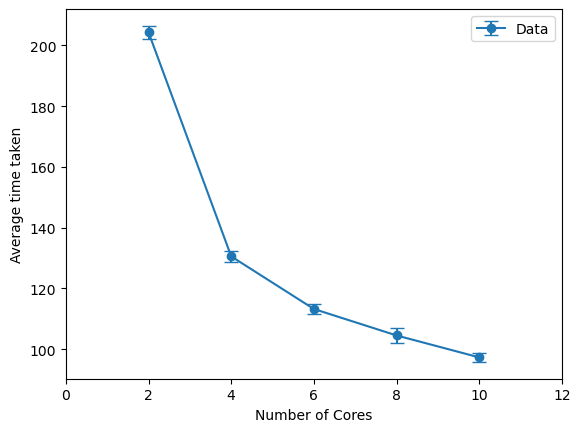

In [7]:
plt.errorbar(core_count, meantimes, yerr=stdtimes, fmt='o-', capsize=5, label='Data')
plt.xlim([0,12])
plt.xlabel('Number of Cores')
plt.ylabel('Average time taken')
plt.legend()
plt.show()